# Deep Learning
## Lab Assignment 8 - MNIST Fashion Dataset Classifier using CNN
Name: Ruta Lole

Roll no.: 61

PRN: 12310305

Class: TY CSAI-A

Batch: 3

## Title:
Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories using CNN.

## Setup

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

## Load and Preprocess the Dataset

In [ ]:
# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape images to add a channel dimension (for CNN input)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28, 1)
y_train shape: (60000,)
60000 train samples
10000 test samples


## Visualize Sample Data
Let's display some sample images from the dataset to understand the data.

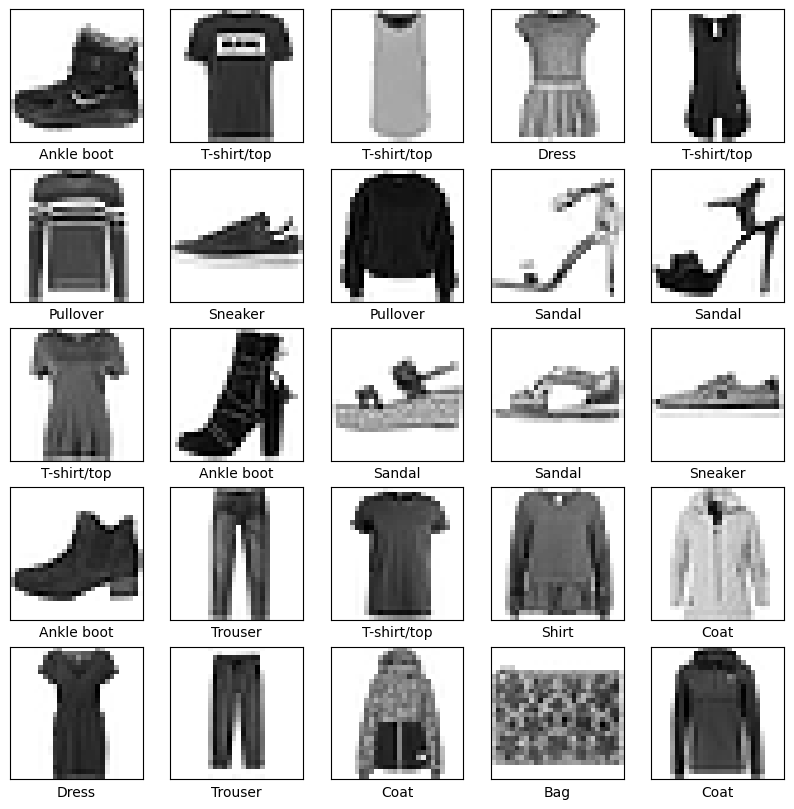

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

## Build the CNN Model

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)), # Input layer
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5), # Dropout for regularization
    layers.Dense(10, activation="softmax"), # Output layer with 10 classes for Fashion MNIST
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

## Train the Model

In [ ]:
batch_size = 128
epochs = 10

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.7516 - loss: 0.6877 - val_accuracy: 0.8350 - val_loss: 0.4475
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.8393 - loss: 0.4489 - val_accuracy: 0.8625 - val_loss: 0.3798
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.8595 - loss: 0.3985 - val_accuracy: 0.8738 - val_loss: 0.3485
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.8692 - loss: 0.3691 - val_accuracy: 0.8825 - val_loss: 0.3336
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.8762 - loss: 0.3475 - val_accuracy: 0.8883 - val_loss: 0.3116
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.8814 - loss: 0.3310 - val_accuracy: 0.8948 - val_loss: 0.3013
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.8845 - loss: 0.3202 - val_accuracy: 0.8970 - val_loss: 0.2907
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.8886 - loss: 0.3100 - 

## Evaluate the Model

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.2919747233390808
Test accuracy: 0.8934999704360962


## Visualize Training Results

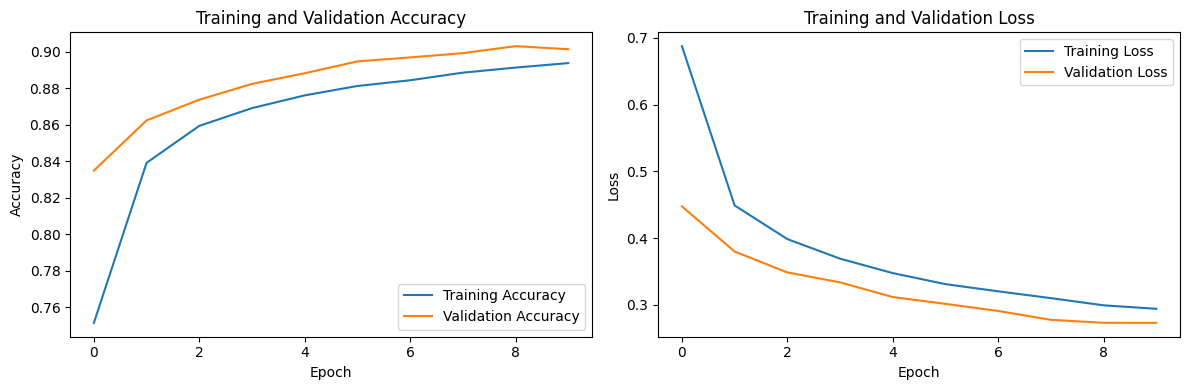

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()